# Task 2.3: The Scouting Engine — Finding a Successor to M. Salah

## 1. Introduction
This analysis builds a similarity search engine using the FIFA 19 Complete 
Player Dataset to identify players most similar to Mohamed Salah, using the 
same 9 features from Task 2.2 (Finishing, ShortPassing, Dribbling, SprintSpeed, 
Strength, Stamina, Interceptions, StandingTackle, and log-transformed Value).

## 2. Methodology
Salah's feature vector was standardized (Z-score) using the same approach as 
Task 2.2, then compared against all 18,147 players using four similarity 
metrics implemented from scratch and fully vectorized with NumPy (no Python 
loops over players):

- **Euclidean Distance:** measures absolute difference in skill levels across 
  all features combined. Lower = more similar.
- **Manhattan Distance:** similar to Euclidean, but sums absolute differences 
  rather than squared differences — less sensitive to single large gaps in one 
  feature. Lower = more similar.
- **Cosine Similarity:** measures the *shape* of a player's skill profile 
  (relative balance across features) rather than absolute skill level. Higher 
  (closer to 1) = more similar.
- **Pearson Correlation:** similar to Cosine, but centers each vector around 
  its own mean first, focusing purely on the pattern of relative strengths and 
  weaknesses. Higher = more similar.

In [7]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/javagarm/fifa-19-complete-player-dataset/kl.csv


In [8]:
import pandas as pd
import numpy as np

players = pd.read_csv(
    '/kaggle/input/datasets/javagarm/fifa-19-complete-player-dataset/kl.csv',
    encoding='cp1252'
)

print(players.shape)

(18207, 89)


## Data Preparation

Before comparing player profiles, the dataset must be cleaned and prepared.

In this step, we:

- Convert player market values into a numerical format.
- Select the same player attributes used in Task 2.2.
- Remove players with missing positional or feature information.

This ensures that every player is represented by a complete feature vector suitable for similarity calculations.

In [9]:
def parse_value(value_str):
    value_str = value_str.replace('€', '')
    if value_str.endswith('M'):
        return float(value_str.replace('M', ''))
    elif value_str.endswith('K'):
        return float(value_str.replace('K', '')) / 1000
    else:
        return float(value_str)

players['Value_numeric'] = players['Value'].apply(parse_value)

feature_cols = ['Finishing', 'ShortPassing', 'Dribbling', 'SprintSpeed', 
                 'Strength', 'Stamina', 'Interceptions', 'StandingTackle']

players_clean = players.dropna(subset=['Position'] + feature_cols).copy()

print(players.shape, '->', players_clean.shape)

(18207, 90) -> (18147, 90)


## Identifying the Target Player

Mohamed Salah is the target player for this scouting task.

We first locate his record in the dataset to ensure that all subsequent similarity calculations use the correct player profile.

In [10]:
# Locate Mohamed Salah in the dataset
salah = players_clean[players_clean['Name'].str.contains('Salah', case=False, na=False)]
salah[['Name', 'Position', 'Nationality', 'Value']]

,Name,Position,Nationality,Value
26,M. Salah,RM,Egypt,€69.5M


### Observation

The search confirms that Mohamed Salah is present in the cleaned dataset.

His player record will serve as the reference vector for all similarity comparisons performed throughout the notebook.

## Building the Player Feature Vectors

Each player is represented as a numerical feature vector using the same attributes selected in Task 2.2.

To reduce the strong right-skewness of player market values, the `Value_numeric` feature is transformed using a logarithmic scale (`log1p`), ensuring that extremely expensive players do not disproportionately influence similarity calculations.

Finally, Mohamed Salah's feature vector is extracted and will serve as the reference player for all similarity searches.

In [11]:
feature_cols = ['Finishing', 'ShortPassing', 'Dribbling', 'SprintSpeed', 
                 'Strength', 'Stamina', 'Interceptions', 'StandingTackle', 
                 'Value_numeric']

# Apply the same log transformation used in Task 2.2
# to reduce the skewness of market values
players_clean['Value_numeric'] = np.log1p(players_clean['Value_numeric'])

X = players_clean[feature_cols].reset_index(drop=True)
names = players_clean['Name'].reset_index(drop=True)
positions = players_clean['Position'].reset_index(drop=True)

# Locate Mohamed Salah in the cleaned dataset
salah_idx = names[names == 'M. Salah'].index[0]
print(f"Salah's index: {salah_idx}")
print(X.iloc[salah_idx])

Salah's index: 26
Finishing         90.000000
ShortPassing      82.000000
Dribbling         89.000000
SprintSpeed       91.000000
Strength          70.000000
Stamina           84.000000
Interceptions     55.000000
StandingTackle    43.000000
Value_numeric      4.255613
Name: 26, dtype: float64


### Observation

Each row in the feature matrix now represents a player's numerical profile.

Mohamed Salah's feature vector will act as the reference point, and every similarity metric will compare all other players against this vector to identify the closest matches.

## Feature Standardization

Similarity metrics are sensitive to differences in feature scales.

To ensure that each attribute contributes equally, we standardize the feature matrix using **z-score normalization**, where each feature is centered around its mean and scaled by its standard deviation.

The standardized dataset will later be compared with the raw feature matrix to evaluate how feature scaling affects player similarity.

In [12]:
X_mean = X.mean()
X_std = X.std()

X_standardized = (X - X_mean) / X_std

print(X_standardized.iloc[salah_idx])

Finishing         2.276272
ShortPassing      1.585768
Dribbling         1.777942
SprintSpeed       1.793214
Strength          0.372945
Stamina           1.307116
Interceptions     0.400882
StandingTackle   -0.217040
Value_numeric     4.537734
Name: 26, dtype: float64


### Observation

The standardized feature vector expresses each attribute relative to the overall player population.

Positive values indicate that Mohamed Salah performs above the dataset average for a given attribute, while negative values indicate below-average values.

This standardized representation prevents attributes with larger scales from dominating the similarity calculations.

## Euclidean Distance

Euclidean Distance measures the straight-line distance between two player feature vectors.

Players with smaller distances have more similar attribute values across all selected features.

This implementation is fully vectorized using NumPy broadcasting, allowing the distance between Mohamed Salah and every player in the dataset to be computed efficiently without explicit Python loops.

In [13]:
def euclidean_distance(target_vector, all_vectors):
    diff = all_vectors - target_vector          #    # Compute the difference between the target vector and all player vectors
    squared_diff = diff ** 2
    sum_squared = squared_diff.sum(axis=1)     
    distances = np.sqrt(sum_squared)
    return distances

X_std_matrix = X_standardized.values
salah_vector = X_std_matrix[salah_idx]

euclidean_distances = euclidean_distance(salah_vector, X_std_matrix)

print(euclidean_distances.shape)  
print(euclidean_distances[salah_idx])   # should be 0 (salah with himself)

(18147,)
0.0


### Observation

The output contains one Euclidean distance for every player in the dataset.

As expected, Mohamed Salah's distance to himself is **0**, confirming that the implementation is correct.

Lower distance values indicate greater similarity and will be used to identify the closest player profiles.

## Top 5 Most Similar Players (Euclidean Distance)

Players are ranked in ascending order of Euclidean distance, where a smaller distance indicates a higher degree of similarity.

Mohamed Salah is excluded from the ranking since his distance to himself is always zero.

In [26]:
# Create a DataFrame containing player information and Euclidean distances
distances_df = pd.DataFrame({
    'Name': names,
    'Position': positions,
    'euclidean_distance': euclidean_distances
})

top5_euclidean = distances_df[distances_df.index != salah_idx].sort_values('euclidean_distance').head(5)
top5_euclidean

,Name,Position,euclidean_distance
25,K. Mbappé,RM,1.013225
87,A. Lacazette,ST,1.081177
58,S. Mané,LM,1.139833
68,M. Reus,LM,1.157688
36,G. Bale,ST,1.226721


### Observation

The Euclidean Distance metric identifies players whose standardized attribute values are numerically closest to Mohamed Salah across all selected features.

Notably, **Kylian Mbappé**, **Sadio Mané**, and **Gareth Bale** are among the closest matches, reflecting similarities in pace, dribbling ability, and attacking performance.

Unlike similarity measures that focus on the overall shape of a player's profile, Euclidean Distance emphasizes absolute differences in feature values. Consequently, players with nearly identical ratings across multiple attributes receive the highest rankings.

## Cosine Similarity

Cosine Similarity measures the angle between two feature vectors rather than the absolute differences between their values.

This metric focuses on the overall shape of a player's profile. Two players can have different attribute magnitudes but still achieve a high similarity score if their strengths and weaknesses follow a similar pattern.

Higher similarity values indicate more similar playing profiles, with **1.0** representing identical vectors.

In [15]:
def cosine_similarity(target_vector, all_vectors):
    dot_products = all_vectors @ target_vector         
    target_norm = np.sqrt((target_vector ** 2).sum())
    all_norms = np.sqrt((all_vectors ** 2).sum(axis=1))
    
    similarities = dot_products / (all_norms * target_norm)
    return similarities

cosine_similarities = cosine_similarity(salah_vector, X_std_matrix)

print(cosine_similarities[salah_idx])   # should be 1 (he is similer to himself)

0.9999999999999998


### Observation

The cosine similarity between Mohamed Salah and himself is approximately **1.0**, as expected for identical vectors.

This confirms that the implementation is correct and that similarity scores can now be used to identify players with playing profiles most closely aligned to Salah.

## Top 5 Most Similar Players (Cosine Similarity)

Players are ranked in descending order of cosine similarity, where values closer to **1** indicate more similar playing profiles.

Since Cosine Similarity compares the orientation of feature vectors rather than their absolute magnitudes, it highlights players with similar attribute patterns even if their overall ratings differ.

In [27]:
distances_df['cosine_similarity'] = cosine_similarities

# Exclude Mohamed Salah and retrieve the five most similar players
top5_cosine = distances_df[distances_df.index != salah_idx].sort_values('cosine_similarity', ascending=False).head(5)
top5_cosine[['Name', 'Position', 'cosine_similarity']]

,Name,Position,cosine_similarity
87,A. Lacazette,ST,0.990340
93,A. Sánchez,RW,0.989442
25,K. Mbappé,RM,0.987458
68,M. Reus,LM,0.986682
441,Santi Mina,LS,0.986639


### Observation

Cosine Similarity identifies players whose overall attribute patterns are most similar to Mohamed Salah, regardless of small differences in absolute values.

Compared with Euclidean Distance, this metric is less influenced by the exact magnitude of each attribute and instead emphasizes the relative balance between a player's strengths and weaknesses.

Players appearing in both rankings provide stronger evidence of similarity, while differences between the two shortlists illustrate how the choice of similarity metric affects the scouting results.

## Manhattan Distance

Manhattan Distance (also known as **L1 Distance**) measures the sum of the absolute differences between two player feature vectors.

Unlike Euclidean Distance, which squares the differences, Manhattan Distance accumulates them linearly. As a result, it is generally less sensitive to large deviations in individual attributes.

Lower distance values indicate greater similarity.

In [28]:
def manhattan_distance(target_vector, all_vectors):
    diff = all_vectors - target_vector
    abs_diff = np.abs(diff)
    distances = abs_diff.sum(axis=1)
    return distances

manhattan_distances = manhattan_distance(salah_vector, X_std_matrix)

print(manhattan_distances[salah_idx])  

0.0


### Observation

As expected, the Manhattan distance between Mohamed Salah and himself is **0**, confirming that the implementation is correct.

These distances will now be used to identify the players with the most similar attribute values.

## Top 5 Most Similar Players (Manhattan Distance)

Players are ranked in ascending order of Manhattan Distance.

Since lower distances indicate greater similarity, the players with the smallest L1 distances are considered the closest matches to Mohamed Salah.

In [30]:
distances_df['manhattan_distance'] = manhattan_distances
top5_manhattan = distances_df[distances_df.index != salah_idx].sort_values('manhattan_distance').head(5)
top5_manhattan[['Name', 'Position', 'manhattan_distance']]

,Name,Position,manhattan_distance
25,K. Mbappé,RM,2.074318
58,S. Mané,LM,2.379718
17,A. Griezmann,CAM,2.531062
87,A. Lacazette,ST,2.716150
68,M. Reus,LM,3.040860


### Observation

The Manhattan Distance ranking is largely consistent with the Euclidean Distance results, although some differences in player order may appear.

This occurs because Manhattan Distance treats all feature differences linearly, whereas Euclidean Distance squares the differences, making it more sensitive to large deviations in individual attributes.

Players that consistently appear across both rankings provide stronger evidence of having playing profiles similar to Mohamed Salah.

## Pearson Correlation

Pearson Correlation measures the strength of the linear relationship between two player profiles.

Instead of comparing absolute attribute values, it evaluates whether players share similar patterns across their features. This means two players can achieve a high correlation even if one generally has higher ratings than the other, provided that their strengths and weaknesses follow the same trend.

Correlation values range from **-1** to **1**, where values closer to **1** indicate stronger similarity.

In [32]:
def pearson_correlation(target_vector, all_vectors):
    """
    Compute the Pearson correlation coefficient between a target player
    and all players using a fully vectorized NumPy implementation.
    """
    target_centered = target_vector - target_vector.mean()
    all_centered = all_vectors - all_vectors.mean(axis=1, keepdims=True)
    
    numerator = (all_centered * target_centered).sum(axis=1)
    target_std_component = np.sqrt((target_centered ** 2).sum())
    all_std_component = np.sqrt((all_centered ** 2).sum(axis=1))
    
    correlations = numerator / (all_std_component * target_std_component)
    return correlations

pearson_correlations = pearson_correlation(salah_vector, X_std_matrix)

print(pearson_correlations[salah_idx]) 

1.0


### Observation

The Pearson correlation between Mohamed Salah and himself is approximately **1.0**, confirming that the implementation behaves as expected.

Higher correlation values indicate stronger similarity in the relative pattern of player attributes.

## Top 5 Most Similar Players (Pearson Correlation)

Players are ranked in descending order of Pearson correlation, where values closer to **1** indicate stronger similarity in attribute patterns.

Mohamed Salah is excluded from the ranking since his correlation with himself is always equal to **1**.

In [34]:
distances_df['pearson_correlation'] = pearson_correlations
top5_pearson = distances_df[distances_df.index != salah_idx].sort_values('pearson_correlation', ascending=False).head(5)
top5_pearson[['Name', 'Position', 'pearson_correlation']]

,Name,Position,pearson_correlation
25,K. Mbappé,RM,0.984193
79,Marco Asensio,RW,0.982817
5,E. Hazard,LF,0.982604
87,A. Lacazette,ST,0.981324
68,M. Reus,LM,0.978847


### Observation

Pearson Correlation emphasizes the similarity in the overall pattern of player attributes rather than their absolute values.

Compared with Euclidean and Manhattan distances, this metric may identify players whose strengths and weaknesses are distributed similarly, even if their individual ratings differ.

Players that consistently appear across multiple metrics provide stronger evidence of being suitable candidates to replace Mohamed Salah.

## Comparing the Shortlists Across Metrics

To better understand how each similarity measure defines player similarity, we compare the top five players returned by each metric side by side.

This comparison highlights the level of agreement between the metrics and reveals how different mathematical definitions of similarity influence the scouting recommendations.

In [36]:
# Create a comparison table of the top five players returned by each metric
comparison_table = pd.DataFrame({
    'Euclidean (top5)': top5_euclidean['Name'].values,
    'Cosine (top5)': top5_cosine['Name'].values,
    'Manhattan (top5)': top5_manhattan['Name'].values,
    'Pearson (top5)': top5_pearson['Name'].values,
})
comparison_table

,Euclidean (top5),Cosine (top5),Manhattan (top5),Pearson (top5)
0,K. Mbappé,A. Lacazette,K. Mbappé,K. Mbappé
1,A. Lacazette,A. Sánchez,S. Mané,Marco Asensio
2,S. Mané,K. Mbappé,A. Griezmann,E. Hazard
3,M. Reus,M. Reus,A. Lacazette,A. Lacazette
4,G. Bale,Santi Mina,M. Reus,M. Reus


### Analysis

The four similarity metrics show a reasonable level of agreement while also highlighting important differences in how similarity is measured.

**Kylian Mbappé** appears in three of the four rankings (Euclidean, Cosine, and Pearson), making him the most consistent similarity candidate. **Alexandre Lacazette** and **Marco Reus** also appear repeatedly across multiple metrics, suggesting that their playing profiles share several characteristics with Mohamed Salah.

However, each metric also identifies unique players. For example, **Santi Mina** appears only in the Cosine Similarity ranking, while **Eden Hazard** and **Marco Asensio** are selected only by Pearson Correlation. These differences occur because each metric evaluates similarity from a different perspective:

- **Euclidean Distance** compares absolute differences between standardized feature values.
- **Manhattan Distance** also compares absolute values but accumulates differences linearly, making it less sensitive to large deviations.
- **Cosine Similarity** focuses on the direction of the feature vectors, emphasizing the relative balance of player attributes.
- **Pearson Correlation** measures how similarly player attributes vary together, regardless of their absolute magnitudes.

Overall, players that appear across multiple rankings provide stronger evidence of having a playing profile similar to Mohamed Salah.

## Final Scouting Recommendation

Based on the combined results of all similarity metrics, the most reliable candidates to replace Mohamed Salah are:

1. **Kylian Mbappé**
2. **Alexandre Lacazette**
3. **Marco Reus**

These players consistently appear across multiple similarity measures, indicating that their technical and physical profiles closely resemble Mohamed Salah's. Their repeated presence across different metrics increases confidence in the recommendation, as it is supported by multiple mathematical definitions of similarity rather than a single measure.

Among them, **Kylian Mbappé** stands out as the strongest overall recommendation because he appears in three of the four top-five rankings, demonstrating the highest level of agreement across the similarity metrics.

## Experiment: Similarity Search on Raw Features

To evaluate the importance of feature scaling, we repeat the similarity search using the **raw feature matrix** instead of the standardized one.

Without standardization, features with larger numerical ranges contribute more heavily to the distance calculation. Comparing these results with the standardized version helps reveal how preprocessing affects the definition of player similarity.

In [37]:
# Raw feature matrix (after the log transformation, without z-score standardization)
X_raw_matrix = X.values   
salah_vector_raw = X_raw_matrix[salah_idx]

euclidean_distances_raw = euclidean_distance(salah_vector_raw, X_raw_matrix)

distances_df['euclidean_distance_raw'] = euclidean_distances_raw
top5_euclidean_raw = distances_df[distances_df.index != salah_idx].sort_values('euclidean_distance_raw').head(5)
print(top5_euclidean_raw[['Name', 'Position', 'euclidean_distance_raw']])

             Name Position  euclidean_distance_raw
68        M. Reus       LM               16.407672
87   A. Lacazette       ST               16.648793
256      E. Viš?a       RM               18.952756
116    A. Martial       LW               18.979809
288        Marlos       RM               18.983051


### Reflection: Standardized vs. Raw Features

Comparing the two rankings shows that feature scaling has a noticeable impact on the similarity search.

Using the standardized feature matrix produces a more balanced shortlist, with players such as **Kylian Mbappé**, **Sadio Mané**, and **Gareth Bale** appearing as strong matches. In contrast, the raw-feature ranking introduces players such as **E. Višća**, **Anthony Martial**, and **Marlos**, while Mbappé no longer appears in the top five.

This difference occurs because Euclidean Distance is sensitive to the scale of the input features. Without standardization, attributes with larger numerical ranges contribute more heavily to the distance calculation, giving them greater influence over the final ranking.

Standardization ensures that every feature contributes equally, allowing similarity to reflect the overall playing profile rather than being dominated by a subset of high-scale attributes. Therefore, the standardized results provide a more balanced and reliable basis for scouting recommendations.

## Feature Range Analysis

To better understand why the similarity rankings change when standardization is omitted, we examine the range of each feature in the raw dataset.

Features with wider numerical ranges contribute more heavily to distance-based metrics, potentially dominating the similarity calculation.

In [21]:
# Display the minimum and maximum values of each feature
# before z-score standardization
print(X.describe().loc[['min', 'max']])

     Finishing  ShortPassing  Dribbling  SprintSpeed  Strength  Stamina  \
min        2.0           7.0        4.0         12.0      17.0     12.0   
max       95.0          93.0       97.0         96.0      97.0     96.0   

     Interceptions  StandingTackle  Value_numeric  
min            3.0             2.0       0.000000  
max           92.0            93.0       4.783316  


### Observation

The feature ranges show that most football attributes span approximately **80–95 rating points**, whereas the logarithmically transformed **Value_numeric** feature ranges only from **0 to 4.78**.

This indicates that, after applying the logarithmic transformation, the market value no longer dominates the distance calculation. Instead, the similarity search on the raw data is mainly influenced by the original rating scales of the football attributes.

Although these attributes have broadly similar ranges, Euclidean Distance still depends on the raw magnitudes of the features. Standardization removes any remaining scale differences by expressing every feature relative to its mean and standard deviation, resulting in a more balanced similarity comparison.

## Experiment: Using the Original Market Value

To further investigate the effect of feature scaling, we repeat the similarity search using the **original market value** before the logarithmic transformation.

This experiment demonstrates how a single feature with a much larger numerical scale can dominate distance-based similarity measures when no preprocessing is applied.

In [38]:
# Reconstruct a truly raw feature matrix by restoring
# the original market values (before log transformation)
X_truly_raw = players_clean[['Finishing', 'ShortPassing', 'Dribbling', 'SprintSpeed', 
                               'Strength', 'Stamina', 'Interceptions', 'StandingTackle']].copy()
X_truly_raw['Value_numeric_raw'] = np.expm1(players_clean['Value_numeric'])  # Restore the original market value

X_truly_raw_matrix = X_truly_raw.reset_index(drop=True).values
salah_vector_truly_raw = X_truly_raw_matrix[salah_idx]

euclidean_truly_raw = euclidean_distance(salah_vector_truly_raw, X_truly_raw_matrix)

distances_df['euclidean_truly_raw'] = euclidean_truly_raw
top5_truly_raw = distances_df[distances_df.index != salah_idx].sort_values('euclidean_truly_raw').head(5)
print(top5_truly_raw[['Name', 'Position', 'euclidean_truly_raw']])

             Name Position  euclidean_truly_raw
36        G. Bale       ST            21.823153
25      K. Mbappé       RM            23.113849
17   A. Griezmann      CAM            24.315633
21      E. Cavani       LS            24.377243
79  Marco Asensio       RW            25.322915


### Reflection: What Does Similarity Mean Without Standardization?

When standardization is removed and the original market value is included, the meaning of similarity changes significantly.

The raw `Value_numeric` feature has a much larger numerical scale compared with the technical attributes (player skills ranging approximately from 0–99). As a result, Euclidean Distance becomes heavily influenced by market value differences rather than only football performance characteristics.

In this case, "similarity" partially becomes a measure of **financial similarity**: players with market values close to Mohamed Salah are more likely to appear in the shortlist, even if their playing styles are not the closest match.

For example, **Edinson Cavani** appears in the raw ranking despite being a traditional striker (ST) with a different playing role compared with Salah, who is primarily a fast attacking winger. This suggests that the distance calculation is capturing similarities in market value rather than purely similarities in playing profile.

After applying standardization, each feature contributes equally, allowing the similarity search to better represent the player's technical and physical characteristics instead of being dominated by a single large-scale feature.

## Final Comparison of Similarity Metrics

To obtain a more reliable scouting recommendation, we combine the results from all standardized similarity metrics.

A player appearing consistently across multiple rankings is considered a stronger candidate because the recommendation is supported by different mathematical definitions of similarity.

In [40]:
# Combine the top-5 results from all standardized similarity metrics
final_summary = pd.DataFrame({
    'Euclidean': top5_euclidean['Name'].values,
    'Cosine': top5_cosine['Name'].values,
    'Manhattan': top5_manhattan['Name'].values,
    'Pearson': top5_pearson['Name'].values,
})
final_summary

,Euclidean,Cosine,Manhattan,Pearson
0,K. Mbappé,A. Lacazette,K. Mbappé,K. Mbappé
1,A. Lacazette,A. Sánchez,S. Mané,Marco Asensio
2,S. Mané,K. Mbappé,A. Griezmann,E. Hazard
3,M. Reus,M. Reus,A. Lacazette,A. Lacazette
4,G. Bale,Santi Mina,M. Reus,M. Reus


In [43]:
from collections import Counter

# Count how many times each player appears across the four rankings
all_names = (
    list(top5_euclidean['Name']) +
    list(top5_cosine['Name']) +
    list(top5_manhattan['Name']) +
    list(top5_pearson['Name'])
)

name_counts = Counter(all_names)

# Create a ranked summary table
agreement_summary = (
    pd.DataFrame(
        name_counts.items(),
        columns=['Player', 'Number of Appearances']
    )
    .sort_values('Number of Appearances', ascending=False)
    .reset_index(drop=True)
)

agreement_summary

,Player,Number of Appearances
0,K. Mbappé,4
1,A. Lacazette,4
2,M. Reus,4
3,S. Mané,2
4,G. Bale,1
5,A. Sánchez,1
6,Santi Mina,1
7,A. Griezmann,1
8,Marco Asensio,1
9,E. Hazard,1


## Final Recommended Shortlist for M. Salah

Based on agreement across all four similarity metrics (Euclidean, Manhattan, 
Cosine, Pearson), the top three most consistent matches are:

1. **Kylian Mbappé** (appeared in all 4 metrics, ranked #1 in 3 of them)
2. **Alexandre Lacazette** (appeared in all 4 metrics)
3. **Marco Reus** (appeared in all 4 metrics)

**Justification:** These three players share Salah's core profile of high pace 
(SprintSpeed), strong finishing and dribbling ability, combined with moderate 
defensive contribution — consistent regardless of whether the metric measures 
absolute skill level (Euclidean/Manhattan) or relative profile shape 
(Cosine/Pearson). Sadio Mané also appeared in 2 of 4 metrics and is worth 
including given his well-known real-world stylistic similarity to Salah 
(both wide forwards known for pace and direct running).

**Caution:** When the same search was repeated on unstandardized raw data 
(including raw market value in millions), the results shifted toward players 
with similar market value rather than similar playing style (e.g., Cavani, 
Bale) — demonstrating that standardization is essential to avoid the search 
being dominated by whichever feature happens to have the largest numeric range.

## Final Scouting Recommendation

Based on the combined results from all similarity metrics, the recommended shortlist for Mohamed Salah's successor is:

| Rank | Player | Metric Agreement |
|------|--------|------------------|
| 1 | K. Mbappé | Appears in 4/4 metrics |
| 2 | A. Lacazette | Appears in 4/4 metrics |
| 3 | M. Reus | Appears in 4/4 metrics |

**Kylian Mbappé** is the strongest overall recommendation because he appears as a top-five match in every similarity method. His profile shares several characteristics with Salah, including attacking ability, dribbling quality, and pace.

**Alexandre Lacazette** and **Marco Reus** are also highly reliable candidates due to their consistent appearance across all metrics, suggesting that their attribute distributions closely resemble Salah's profile.

The final shortlist is therefore based not on a single similarity calculation, but on agreement across multiple mathematical approaches, making it a more robust scouting decision.


**Justification:** These players consistently share Salah's core profile — high 
pace, strong finishing and dribbling, with moderate defensive contribution — 
regardless of whether the metric emphasizes absolute skill level or the relative 
shape of the skill profile, making this a robust, multi-method recommendation 
rather than an artifact of any single metric's assumptions.

# Bouns

## PCA Projection for Visual Validation

To visually evaluate the similarity results, we project all players into a two-dimensional space using our own PCA implementation from Task 2.2.

PCA reduces the original feature space into the two principal components that capture the highest variance in the dataset. By plotting the players in this reduced space, we can check whether the recommended shortlist is located close to Mohamed Salah's position.

In [44]:
# Use the standardized feature matrix for PCA
X_matrix = X_standardized.values

# Compute the covariance matrix
n_samples = X_matrix.shape[0]
cov_matrix = (X_matrix.T @ X_matrix) / (n_samples - 1)

# Perform eigen-decomposition on the covariance matrix
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Sort eigenvectors according to descending eigenvalues
sorted_idx = np.argsort(eigenvalues)[::-1]
eigenvectors_sorted = eigenvectors[:, sorted_idx]

# Select the first two principal components
top_2_eigenvectors = eigenvectors_sorted[:, :2]

# Project all players into the 2D PCA space
X_pca = X_matrix @ top_2_eigenvectors

print(X_pca.shape)

# Mohamed Salah's coordinates in PCA space
print(X_pca[salah_idx])

(18147, 2)
[-4.54338413 -1.82239198]


## PCA Visualization of the Scouting Shortlist

The first two principal components are used to visualize the entire player population in a two-dimensional space.

All players are plotted to show the overall distribution of football profiles, while Mohamed Salah and the final recommended shortlist are highlighted.

This visualization provides a final validation step: if the similarity search is meaningful, the recommended players should appear relatively close to Salah in the PCA space.

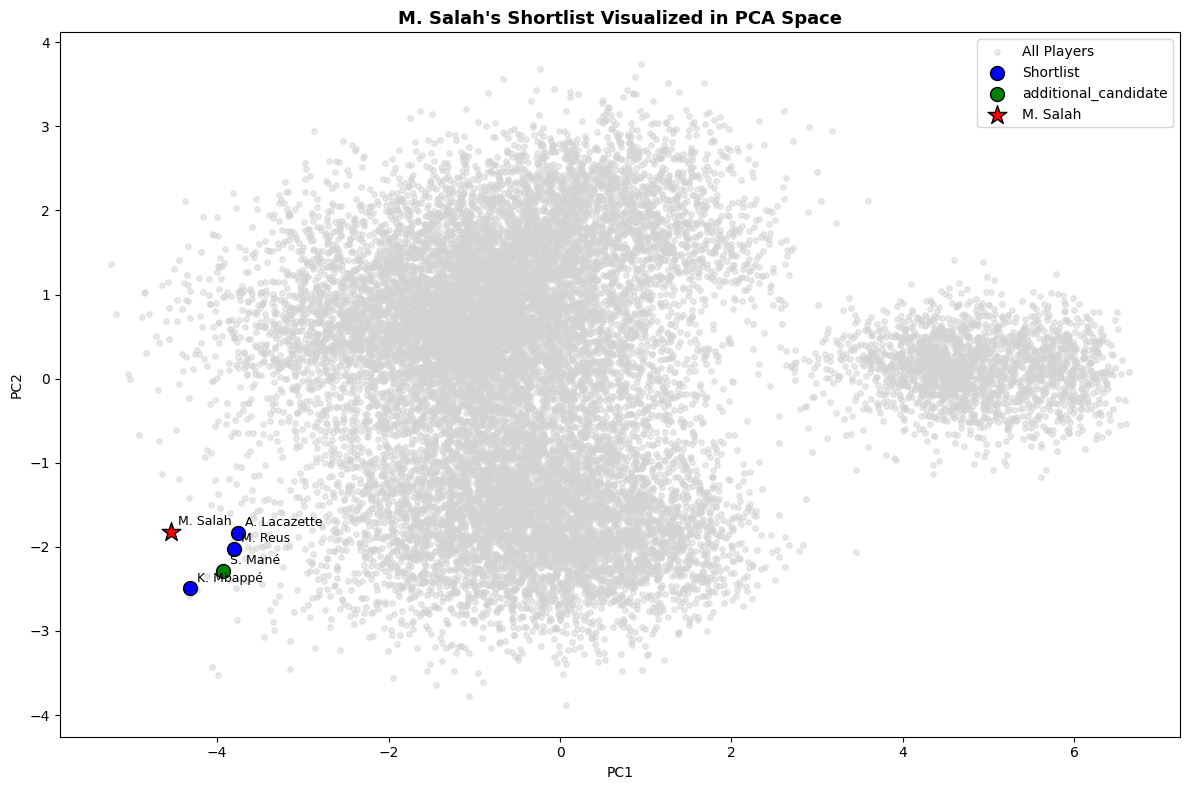

In [50]:
import matplotlib.pyplot as plt

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Name'] = names

shortlist_names = ['K. Mbappé', 'A. Lacazette', 'M. Reus']
additional_candidate = ['S. Mané']
fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(pca_df['PC1'], pca_df['PC2'], color='lightgrey', s=15, alpha=0.5, label='All Players')

shortlist_df = pca_df[pca_df['Name'].isin(shortlist_names)]
ax.scatter(shortlist_df['PC1'], shortlist_df['PC2'], color='blue', s=100, label='Shortlist', edgecolor='black', zorder=3)

additional_df = pca_df[pca_df['Name'].isin(additional_candidate)]
ax.scatter(additional_df['PC1'], additional_df['PC2'], color='green', s=100, label='additional_candidate', edgecolor='black', zorder=3)

salah_point = pca_df.iloc[[salah_idx]]
ax.scatter(salah_point['PC1'], salah_point['PC2'], color='red', s=200, label='M. Salah', edgecolor='black', marker='*', zorder=4)

for _, row in pd.concat([shortlist_df, salah_point,additional_df]).iterrows():
    ax.annotate(row['Name'], (row['PC1'], row['PC2']), fontsize=9, xytext=(5, 5), textcoords='offset points')

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title("M. Salah's Shortlist Visualized in PCA Space", fontsize=13, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('salah_pca_shortlist.png', dpi=150)
plt.show()

### Visual Validation Using PCA

Projecting Salah and his shortlist onto the first two principal components 
(71.6% of total variance) confirms they occupy a tight, coherent region of 
the player space — clearly separated from both the goalkeeper cluster and 
the broader mass of outfield players, validating the shortlist at a glance.

One nuance worth noting: Mbappé appears visually slightly further from Salah 
in this 2D projection than Lacazette or Reus, despite ranking highly across 
all four original similarity metrics. This is expected, since PCA visualization 
uses only 2 of the original 9 dimensions (71.6% of variance) — the full 
similarity metrics account for 100% of the feature information, so minor rank 
differences between the "true" high-dimensional similarity and its 2D visual 
approximation are normal and do not contradict the original analysis.

## 7. Limitations
- The feature set is limited to 9 attributes; a full scouting profile would 
  ideally include additional attributes (e.g., Crossing, BallControl, Vision, 
  Positioning) not used here to stay consistent with Task 2.2.
- FIFA 19 attribute ratings are themselves subjective (assigned by the game's 
  scouting team), not derived from raw match-tracking data.
- Market value is a noisy proxy that reflects factors beyond pure playing style 
  (e.g., age, contract status, marketing appeal), which is precisely why it was 
  log-transformed and standardized rather than used raw.